<a href="https://colab.research.google.com/github/vidya-061/DAY5_BOOTCAMP/blob/main/04_07_2026_bootcamp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### TO CREATE A NEURAL NETWORK

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
(X_train, Y_train), (X_test, Y_test) = tf.keras.datasets.cifar10.load_data()

In [ ]:
print(X_train.shape)
print(X_train.shape)

(50000, 32, 32, 3)
(50000, 32, 32, 3)


In [ ]:
print(Y_train[:10])

[[6]
 [9]
 [9]
 [4]
 [1]
 [1]
 [2]
 [7]
 [8]
 [3]]


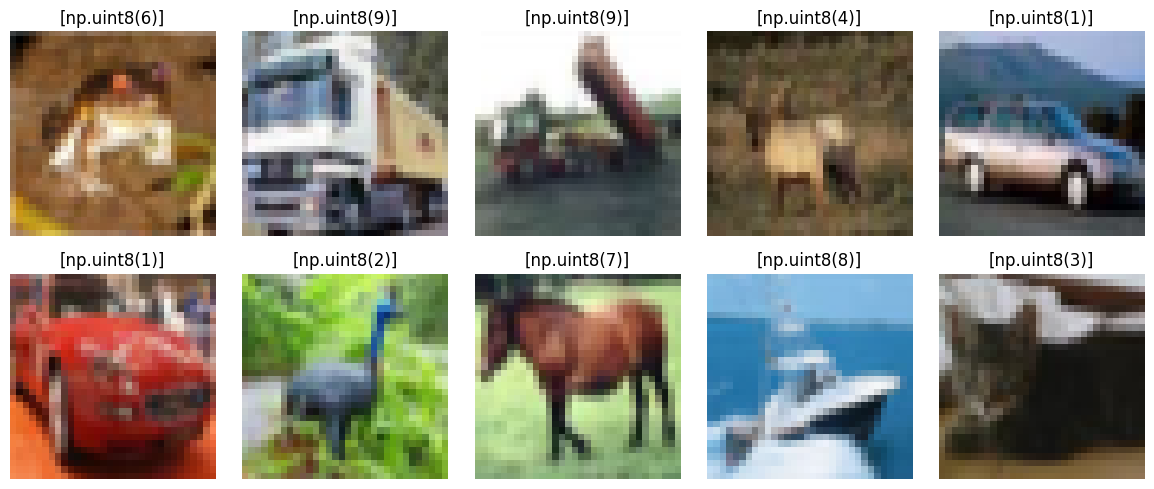

In [ ]:
plt.figure(figsize=(12,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i])
    plt.title([Y_train[i][0]])
    plt.axis("off")
    plt.tight_layout()
plt.show()

In [ ]:
class_names = [
    'Airplane',
    'Automobile',
    'Bird',
    'Cat',
    'Deer',
    'Dog',
    'Frog',
    'Horse',
    'Ship',
    'Truck'
]

In [ ]:
print(X_train[0])

[[[ 59  62  63]
  [ 43  46  45]
  [ 50  48  43]
  ...
  [158 132 108]
  [152 125 102]
  [148 124 103]]

 [[ 16  20  20]
  [  0   0   0]
  [ 18   8   0]
  ...
  [123  88  55]
  [119  83  50]
  [122  87  57]]

 [[ 25  24  21]
  [ 16   7   0]
  [ 49  27   8]
  ...
  [118  84  50]
  [120  84  50]
  [109  73  42]]

 ...

 [[208 170  96]
  [201 153  34]
  [198 161  26]
  ...
  [160 133  70]
  [ 56  31   7]
  [ 53  34  20]]

 [[180 139  96]
  [173 123  42]
  [186 144  30]
  ...
  [184 148  94]
  [ 97  62  34]
  [ 83  53  34]]

 [[177 144 116]
  [168 129  94]
  [179 142  87]
  ...
  [216 184 140]
  [151 118  84]
  [123  92  72]]]


In [ ]:
X_train = X_train /255

X_test = X_test /255
print("Minimum :", X_train.min())
print("Maximum :", X_train.max())

Minimum : 0.0
Maximum : 1.0


In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(
        32,
        (3,3),
        activation="relu",
        input_shape=(32,32,3)
      ),

    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(
        64,
        (3,3),
        activation="relu"
    ),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(
        64,
        activation="relu"
    ),
    tf.keras.layers.Dense(
        10,
        activation="softmax"
    )
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history = model.fit(
    X_train,
    Y_train,
    epochs=10,
    batch_size=23,
    validation_split=0.2
)

Epoch 1/10
1740/1740 ━━━━━━━━━━━━━━━━━━━━ 65s 36ms/step - accuracy: 0.4548 - loss: 1.5164 - val_accuracy: 0.5578 - val_loss: 1.2507
Epoch 2/10
1740/1740 ━━━━━━━━━━━━━━━━━━━━ 83s 37ms/step - accuracy: 0.5860 - loss: 1.1697 - val_accuracy: 0.5943 - val_loss: 1.1565
Epoch 3/10
1740/1740 ━━━━━━━━━━━━━━━━━━━━ 84s 48ms/step - accuracy: 0.6390 - loss: 1.0333 - val_accuracy: 0.6305 - val_loss: 1.0532
Epoch 4/10
1740/1740 ━━━━━━━━━━━━━━━━━━━━ 68s 39ms/step - accuracy: 0.6711 - loss: 0.9416 - val_accuracy: 0.6590 - val_loss: 0.9862
Epoch 5/10
1740/1740 ━━━━━━━━━━━━━━━━━━━━ 62s 35ms/step - accuracy: 0.6963 - loss: 0.8740 - val_accuracy: 0.6631 - val_loss: 0.9756
Epoch 6/10
1740/1740 ━━━━━━━━━━━━━━━━━━━━ 60s 34ms/step - accuracy: 0.7150 - loss: 0.8152 - val_accuracy: 0.6727 - val_loss: 0.9581
Epoch 7/10
1740/1740 ━━━━━━━━━━━━━━━━━━━━ 82s 35ms/step - accuracy: 0.7343 - loss: 0.7612 - val_accuracy: 0.6714 - val_loss: 0.9684
Epoch 8/10
1740/1740 ━━━━━━━━━━━━━━━━━━━━ 60s 34ms/step - accuracy: 0.7499 -

In [ ]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


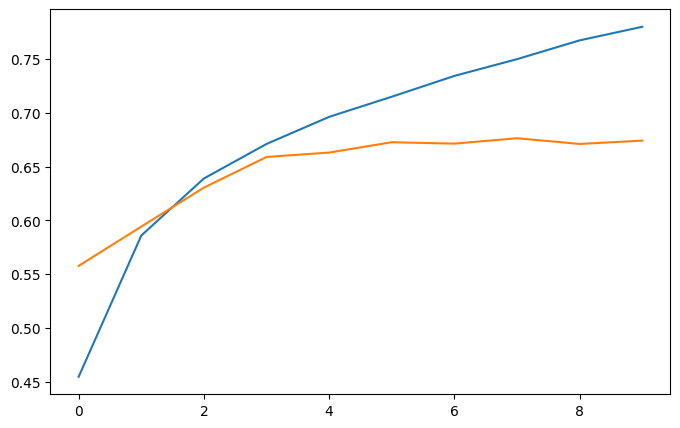

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.show()

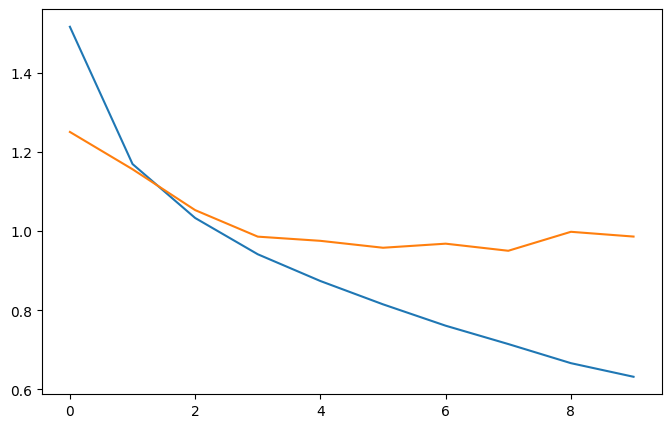

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.show()

In [ ]:
predictions = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step


In [ ]:
predicted_label =np.argmax(predictions[0])
print("predicted Digit :", predicted_label)
print("Actual Digit :", Y_test[0])

predicted Digit : 3
Actual Digit : [3]


In [ ]:
import numpy as np
y_pred = np.argmax(prediction, axis=1)

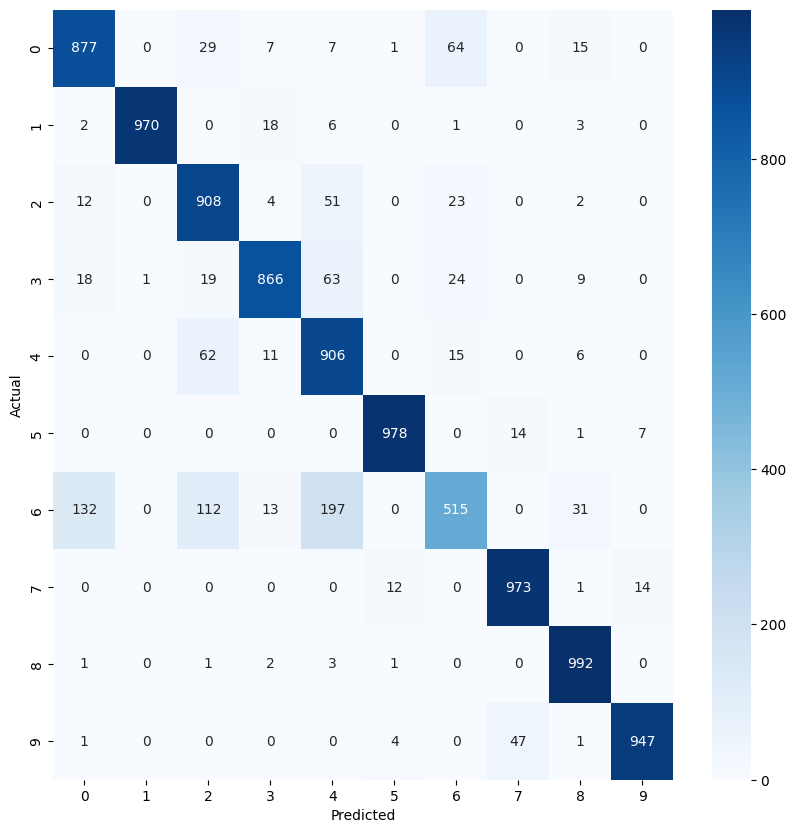

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = np.argmax(prediction, axis=1)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
classification_report(Y_test, y_pred)

'              precision    recall  f1-score   support\n\n           0       0.71      0.70      0.71      1000\n           1       0.86      0.73      0.79      1000\n           2       0.45      0.69      0.54      1000\n           3       0.50      0.48      0.49      1000\n           4       0.64      0.54      0.59      1000\n           5       0.60      0.54      0.57      1000\n           6       0.71      0.80      0.75      1000\n           7       0.83      0.68      0.74      1000\n           8       0.77      0.80      0.79      1000\n           9       0.78      0.74      0.76      1000\n\n    accuracy                           0.67     10000\n   macro avg       0.69      0.67      0.67     10000\nweighted avg       0.69      0.67      0.67     10000\n'


## convolution neural network example fashion_mnist

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
import matplotlib.pyplot as plt

In [ ]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print(X_train.shape)
print(X_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28)
(10000, 28, 28)


In [ ]:
print(y_train[:10])

[9 0 0 3 0 2 7 2 5 5]


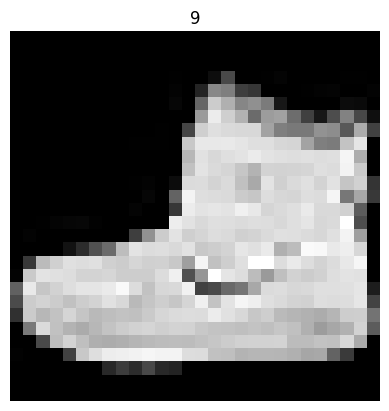

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(X_train[0], cmap='gray')
plt.title(y_train[0])
plt.axis('off')
plt.show()

In [ ]:
print(X_train[0])

[[[0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]]

 [[0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]]

 [[0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0. 

In [ ]:
X_train = X_train /255

X_test = X_test /255
print("Minimum :", X_train.min())
print("Maximum :", X_train.max())

Minimum : 0.0
Maximum : 0.00392156862745098


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.datasets import fashion_mnist


(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()


X_train = X_train / 255.0
X_test = X_test / 255.0


X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

model = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    MaxPooling2D((2,2)),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128,activation='relu'),

    Dense(10,activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 68s 44ms/step - accuracy: 0.8280 - loss: 0.4698 - val_accuracy: 0.8787 - val_loss: 0.3351
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 70s 36ms/step - accuracy: 0.8839 - loss: 0.3125 - val_accuracy: 0.8914 - val_loss: 0.3008
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 52s 34ms/step - accuracy: 0.9009 - loss: 0.2651 - val_accuracy: 0.9000 - val_loss: 0.2712
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 51s 34ms/step - accuracy: 0.9135 - loss: 0.2339 - val_accuracy: 0.9059 - val_loss: 0.2608
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 51s 34ms/step - accuracy: 0.9242 - loss: 0.2047 - val_accuracy: 0.9103 - val_loss: 0.2423


In [ ]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8971 - loss: 0.2793
Accuracy: 0.8970999717712402


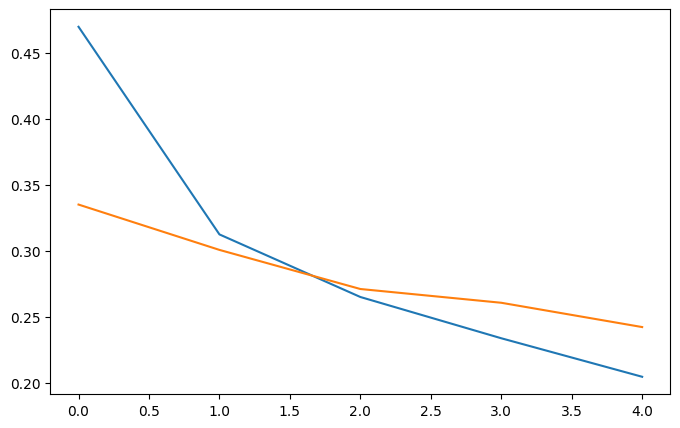

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.show()

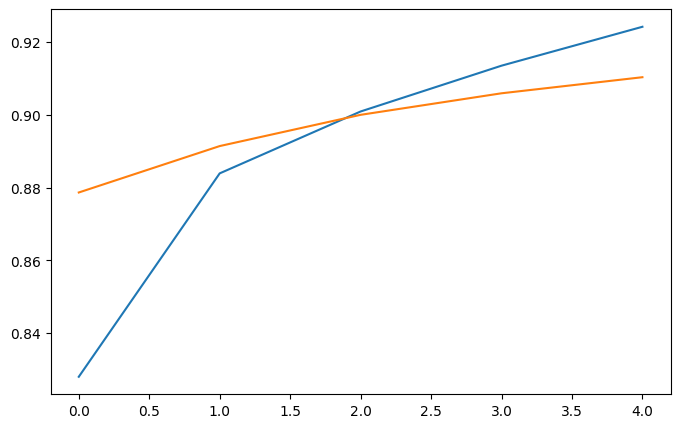

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.show()

In [ ]:
predictions = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step


In [ ]:
print("Predicted:", prediction[0].argmax())
print("Actual:", y_test[0])

Predicted: 9
Actual: 9


In [ ]:
class_names = [
    "T-shirt/Top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]


In [ ]:
import numpy as np
y_pred = np.argmax(prediction, axis=1)

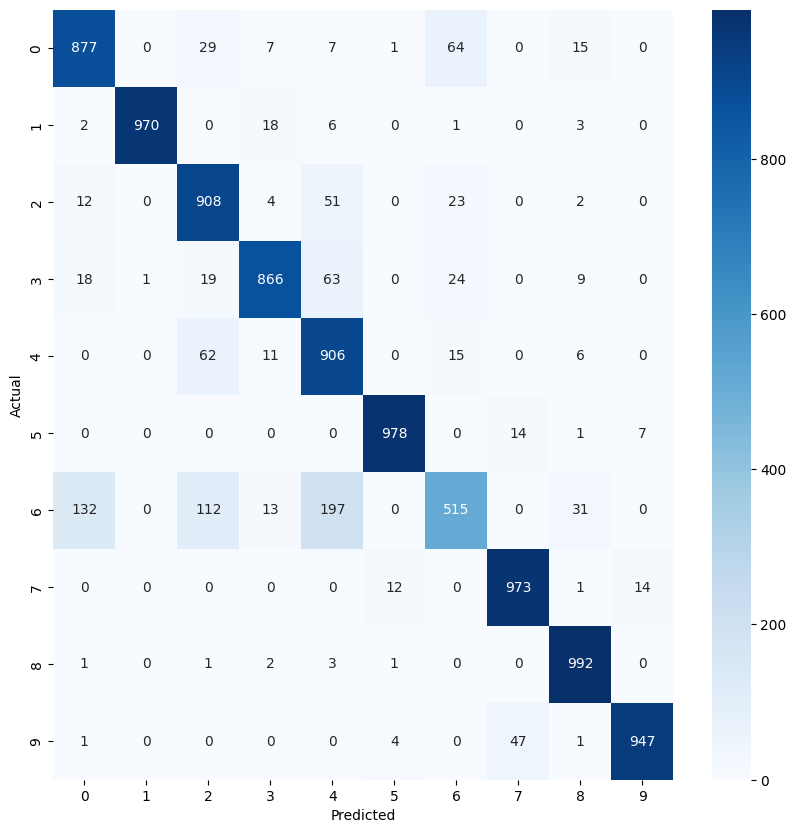

In [ ]:
y_pred = np.argmax(prediction, axis=1)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
from sklearn.metrics import classification_report
classification_report(y_test, y_pred)

'              precision    recall  f1-score   support\n\n           0       0.84      0.88      0.86      1000\n           1       1.00      0.97      0.98      1000\n           2       0.80      0.91      0.85      1000\n           3       0.94      0.87      0.90      1000\n           4       0.73      0.91      0.81      1000\n           5       0.98      0.98      0.98      1000\n           6       0.80      0.52      0.63      1000\n           7       0.94      0.97      0.96      1000\n           8       0.93      0.99      0.96      1000\n           9       0.98      0.95      0.96      1000\n\n    accuracy                           0.89     10000\n   macro avg       0.90      0.89      0.89     10000\nweighted avg       0.90      0.89      0.89     10000\n'